
**Snapshots used:** 99 (z=0), 51 (z≈0.95), 33 (z≈2), 17 (z≈5).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from scipy.sparse.linalg import eigsh
import pycorr
from pycorr import TwoPointCorrelationFunction


SNAPS = [17, 33, 51, 99]
REDSHIFTS = {99: 0.0, 51: 0.95, 33: 2.0, 17: 5.0}
H = 0.6774  # TNG cosmology

## Load Embeddings, Progenitors, and Properties

In [27]:
# Load all 4 embeddings
emb = {}
for s in SNAPS:
    d = np.load(f'snapshot{s}_embedding_r2.npz')
    emb[s] = {
        'embedding': d['embedding'],
        'original_index': d['original_index'].astype(int),
        'sorted_neighbors': d['sorted_neighbors'],
    }
    print(f'snap {s}: {emb[s]["embedding"].shape[0]} galaxies')

# Load progenitor matches and properties
prog = pd.read_csv('progenitors_multi.csv')
props = pd.read_csv('progenitor_properties.csv')
print(f'progenitors_multi.csv: {len(prog)} rows')
print(f'progenitor_properties.csv: {len(props)} rows')

snap 17: 2501 galaxies
snap 33: 10000 galaxies
snap 51: 10000 galaxies
snap 99: 10000 galaxies
progenitors_multi.csv: 10000 rows
progenitor_properties.csv: 10000 rows


In [28]:
# Build SubfindID -> embedding-row lookup tables per snapshot
sid_to_row = {s: {int(sid): i for i, sid in enumerate(emb[s]['original_index'])} for s in SNAPS}

# For each z=0 galaxy, find its embedding-row at every snapshot (or -1 if not present)
n_z0 = len(prog)
row_at = {s: np.full(n_z0, -1, dtype=int) for s in SNAPS}
for i, r in prog.iterrows():
    row_at[99][i] = sid_to_row[99].get(int(r['subfind_z0']), -1)
    for s in [51, 33, 17]:
        col = f'subfind_snap_{s}'
        if pd.notna(r[col]):
            row_at[s][i] = sid_to_row[s].get(int(r[col]), -1)

# Mask: z=0 galaxies that have a progenitor present in the embedding at every snapshot
all_present = np.ones(n_z0, dtype=bool)
for s in SNAPS:
    all_present &= (row_at[s] >= 0)
print(f'Galaxies with progenitors in all 4 embeddings: {all_present.sum()} / {n_z0}')

Galaxies with progenitors in all 4 embeddings: 1062 / 10000


## Nyström Projection of Earlier Snapshots into z=0 Space

Use snap 99's centering statistics, eigenvalues, and eigenvectors as the fixed reference frame; project the sorted-neighbor vectors of every other snapshot through it.

In [29]:
# Truncate every snapshot's sorted-neighbor vectors to the smallest common width,
# keeping the LAST columns (which contain the actual neighbor distances).
min_cols = min(emb[s]['sorted_neighbors'].shape[1] for s in SNAPS)
print(f'Truncating all sorted-neighbor vectors to last {min_cols} columns')
sn = {s: emb[s]['sorted_neighbors'][:, -min_cols:] for s in SNAPS}

# Within-snapshot z=0 similarity matrix (using truncated vectors)
D_z0 = euclidean_distances(sn[99])
col_means_z0 = D_z0.mean(axis=0)
grand_mean_z0 = D_z0.mean()
print(f'D_z0 shape: {D_z0.shape}, grand mean: {grand_mean_z0:.3f}')

Truncating all sorted-neighbor vectors to last 2501 columns
D_z0 shape: (10000, 10000), grand mean: 4.093


In [30]:
emb[99]['embedding'].shape

(10000, 10)

In [2]:
data99 = np.load('snapshot99_embedding.npz')
positions_z0 = data99['positions']   # shape (N, 3): [x, y, z] per galaxy
print(positions_z0.shape)

(10000, 3)


In [3]:
data99['embedding'].shape

(10000, 10)

In [18]:
boxsize = 75.0
edges = np.logspace(np.log10(0.5), np.log10(30.0), 25)        # s bin edges in Mpc/h

# all z=0 positions, row-aligned with X[99]
positions_z0 = np.load('snapshot99_embedding.npz')['positions']   # (N, 3) Mpc/h

# top third of embedding Dim 1
dim1   = data99['embedding'][:, 0]
thresh = np.percentile(dim1, 100 * 1/5) 
top_mask = dim1 <= thresh
print(f"all: {len(positions_z0)},  top third of Dim 1: {top_mask.sum()}")

pos_all = positions_z0
pos_top = positions_z0[top_mask]

result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T,              # all galaxies
    data_positions2=pos_top.T,              # quanitle
    los='z',
    boxsize=boxsize,
)

s, xi = result(return_sep=True)
for r, x in zip(s, xi):
    print(f"s = {r:6.2f} Mpc/h   xi = {x:+.4f}")


all: 10000,  top third of Dim 1: 2000
s =   0.55 Mpc/h   xi = +257.3138
s =   0.65 Mpc/h   xi = +211.0040
s =   0.77 Mpc/h   xi = +148.1726
s =   0.91 Mpc/h   xi = +109.3983
s =   1.08 Mpc/h   xi = +77.4713
s =   1.28 Mpc/h   xi = +51.2154
s =   1.52 Mpc/h   xi = +32.9051
s =   1.80 Mpc/h   xi = +20.7347
s =   2.14 Mpc/h   xi = +15.7206
s =   2.54 Mpc/h   xi = +12.7915
s =   3.02 Mpc/h   xi = +9.9159
s =   3.58 Mpc/h   xi = +8.2206
s =   4.24 Mpc/h   xi = +5.8088
s =   5.01 Mpc/h   xi = +3.9740
s =   5.96 Mpc/h   xi = +2.3698
s =   7.08 Mpc/h   xi = +1.5368
s =   8.40 Mpc/h   xi = +1.1085
s =   9.94 Mpc/h   xi = +0.8779
s =  11.82 Mpc/h   xi = +0.4252
s =  14.01 Mpc/h   xi = +0.2599
s =  16.63 Mpc/h   xi = +0.1137
s =  19.76 Mpc/h   xi = +0.1029
s =  23.38 Mpc/h   xi = -0.0284
s =  27.81 Mpc/h   xi = -0.1041


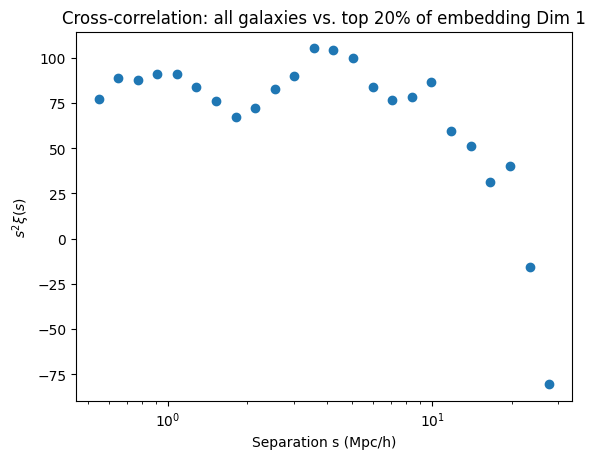

In [20]:
plt.plot(s, s**2 * xi, 'o')
plt.xlabel('Separation s (Mpc/h)')
plt.ylabel("$s^2 \\xi(s)$")
plt.title('Cross-correlation: all galaxies vs. top 20% of embedding Dim 1')
plt.xscale('log')
plt.show()

In [21]:
boxsize = 75.0
edges = np.logspace(np.log10(0.5), np.log10(30.0), 25)        # s bin edges in Mpc/h

# all z=0 positions, row-aligned with X[99]
positions_z0 = np.load('snapshot99_embedding.npz')['positions']   # (N, 3) Mpc/h

# top third of embedding Dim 1
dim1   = data99['embedding'][:, 0]
thresh = np.percentile(dim1, 100 * 4/5) 
top_mask = dim1 >= thresh
print(f"all: {len(positions_z0)},  top third of Dim 1: {top_mask.sum()}")

pos_all = positions_z0
pos_top = positions_z0[top_mask]

result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T,              # all galaxies
    data_positions2=pos_top.T,              # quanitle
    los='z',
    boxsize=boxsize,
)

s, xi = result(return_sep=True)
for r, x in zip(s, xi):
    print(f"s = {r:6.2f} Mpc/h   xi = {x:+.4f}")

all: 10000,  top third of Dim 1: 2000
s =   0.54 Mpc/h   xi = +12.2623
s =   0.65 Mpc/h   xi = +6.1547
s =   0.78 Mpc/h   xi = +4.4367
s =   0.91 Mpc/h   xi = +3.5182
s =   1.09 Mpc/h   xi = +2.1597
s =   1.28 Mpc/h   xi = +1.5611
s =   1.53 Mpc/h   xi = +0.9239
s =   1.81 Mpc/h   xi = +0.5923
s =   2.15 Mpc/h   xi = +0.2559
s =   2.54 Mpc/h   xi = -0.1261
s =   3.00 Mpc/h   xi = -0.2701
s =   3.59 Mpc/h   xi = -0.3404
s =   4.25 Mpc/h   xi = -0.4355
s =   5.08 Mpc/h   xi = -0.3404
s =   5.99 Mpc/h   xi = -0.1868
s =   7.10 Mpc/h   xi = -0.1324
s =   8.43 Mpc/h   xi = -0.0836
s =   9.99 Mpc/h   xi = -0.0073
s =  11.84 Mpc/h   xi = +0.0007
s =  14.04 Mpc/h   xi = -0.0138
s =  16.66 Mpc/h   xi = -0.0007
s =  19.75 Mpc/h   xi = +0.0060
s =  23.43 Mpc/h   xi = +0.0115
s =  27.78 Mpc/h   xi = +0.0079


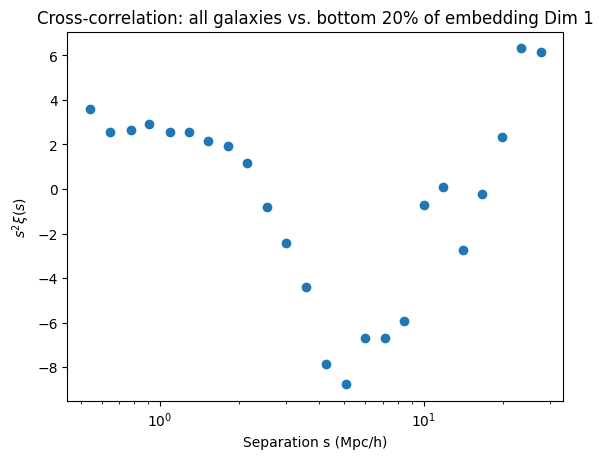

In [22]:
plt.plot(s, s**2 * xi, 'o')
plt.xlabel('Separation s (Mpc/h)')
plt.ylabel("$s^2 \\xi(s)$")
plt.title('Cross-correlation: all galaxies vs. bottom 20% of embedding Dim 1')
plt.xscale('log')
plt.show()

s =   0.55 Mpc/h   xi = +96.6348
s =   0.65 Mpc/h   xi = +72.3396
s =   0.77 Mpc/h   xi = +48.4195
s =   0.91 Mpc/h   xi = +34.9590
s =   1.08 Mpc/h   xi = +24.0722
s =   1.28 Mpc/h   xi = +16.4621
s =   1.52 Mpc/h   xi = +10.5767
s =   1.81 Mpc/h   xi = +6.7459
s =   2.14 Mpc/h   xi = +5.0428
s =   2.54 Mpc/h   xi = +3.8551
s =   3.01 Mpc/h   xi = +2.9486
s =   3.58 Mpc/h   xi = +2.3176
s =   4.24 Mpc/h   xi = +1.6766
s =   5.03 Mpc/h   xi = +1.2550
s =   5.97 Mpc/h   xi = +0.9105
s =   7.09 Mpc/h   xi = +0.6150
s =   8.40 Mpc/h   xi = +0.4401
s =   9.97 Mpc/h   xi = +0.3430
s =  11.82 Mpc/h   xi = +0.1911
s =  14.03 Mpc/h   xi = +0.1175
s =  16.64 Mpc/h   xi = +0.0619
s =  19.75 Mpc/h   xi = +0.0465
s =  23.40 Mpc/h   xi = -0.0107
s =  27.79 Mpc/h   xi = -0.0439


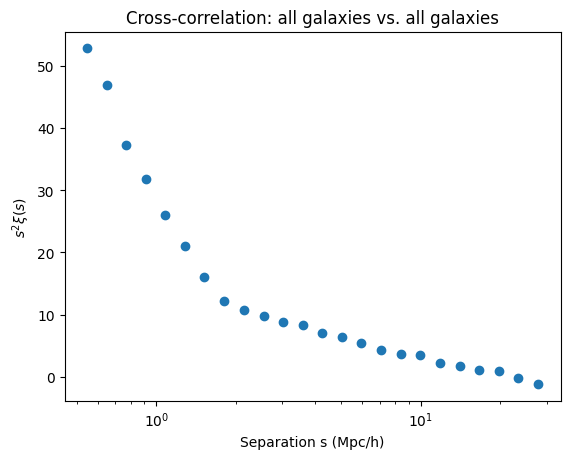

In [25]:
result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T,              # all galaxies
    data_positions2=pos_all.T,              # quanitle
    los='z',
    boxsize=boxsize,
)

s, xi = result(return_sep=True)
for r, x in zip(s, xi):
    print(f"s = {r:6.2f} Mpc/h   xi = {x:+.4f}")

plt.plot(s, s * xi, 'o')
plt.xlabel('Separation s (Mpc/h)')
plt.ylabel("$s^2 \\xi(s)$")
plt.title('Cross-correlation: all galaxies vs. all galaxies')
plt.xscale('log')
plt.show()